In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


In [2]:
!pip install dagshub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 kB 6.2 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 4.2 MB/s eta 0:00:00
  Attempting uninstall: dacite
    Found existing installation: dacite 1.9.2
    Uninstalling dacite-1.9.2:
      Successfully uninstalled dacite-1.9.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydata-profiling 4.18.1 requires dacite<2,>=1.9, but you have dacite 1.6.0 which is incompatible.


In [3]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 73.6 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 54.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 39.2 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 27.3 MB/s eta 0:00:00


In [4]:
import dagshub
import mlflow
dagshub.init(repo_owner='mkekn23', repo_name='ML-assignment-1', mlflow=True)


❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=001ee9e5-6a5f-4af1-ae8d-4f12c375f3bc&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=88cfb08d525b1000a5ddc24fbbba6cb7ee08329565f397ab137ef2d09532ef1b




Accessing as mkekn23

Initialized MLflow to track repo "mkekn23/ML-assignment-1"

Repository mkekn23/ML-assignment-1 initialized!

# Cleaning

In [5]:
df= pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv")
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [7]:
df.shape

(1460, 81)

In [8]:
X_train.shape

(1168, 80)

In [9]:
X_test.shape

(292, 80)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

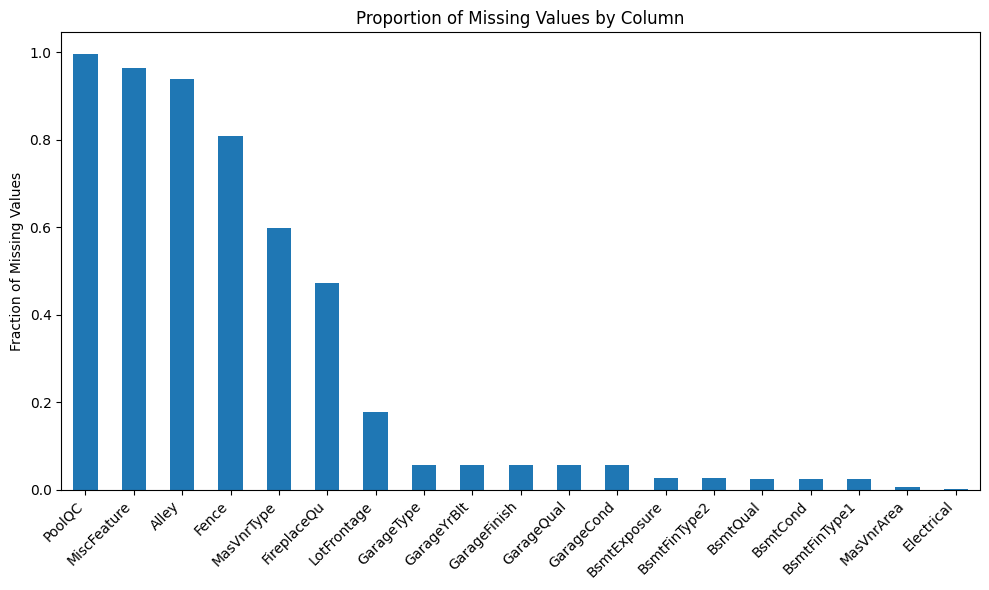

In [11]:
import matplotlib.pyplot as plt

null_ratio = df.isna().sum() / df.shape[0]
null_ratio = null_ratio[null_ratio > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
null_ratio.plot(kind='bar')
plt.title('Proportion of Missing Values by Column')
plt.ylabel('Fraction of Missing Values')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [12]:
missing_info = X_train.isnull().sum()
missing_info = missing_info[missing_info > 0].sort_values(ascending=False)
print(missing_info)

PoolQC          1162
MiscFeature     1122
Alley           1094
Fence            935
MasVnrType       683
FireplaceQu      547
LotFrontage      217
GarageType        64
GarageYrBlt       64
GarageFinish      64
GarageQual        64
GarageCond        64
BsmtCond          28
BsmtFinType1      28
BsmtExposure      28
BsmtQual          28
BsmtFinType2      28
MasVnrArea         6
Electrical         1
dtype: int64


In [13]:
missing_info = X_test.isnull().sum()
missing_info = missing_info[missing_info > 0].sort_values(ascending=False)
print(missing_info)

PoolQC          291
MiscFeature     284
Alley           275
Fence           244
MasVnrType      189
FireplaceQu     143
LotFrontage      42
GarageType       17
GarageFinish     17
GarageQual       17
GarageYrBlt      17
GarageCond       17
BsmtFinType2     10
BsmtExposure     10
BsmtCond          9
BsmtFinType1      9
BsmtQual          9
MasVnrArea        2
dtype: int64


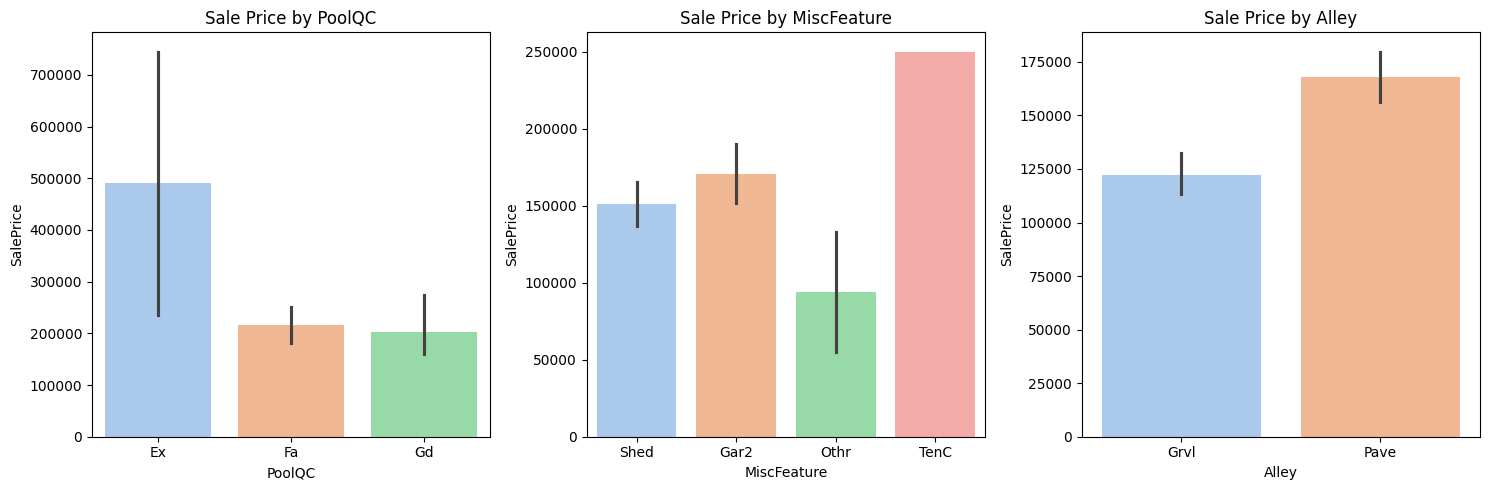

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

train_plot = df.copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# PoolQC
sns.barplot(x='PoolQC', y='SalePrice', data=train_plot, ax=axes[0], palette='pastel', hue='PoolQC', legend=False)
axes[0].set_title('Sale Price by PoolQC')

# MiscFeature
sns.barplot(x='MiscFeature', y='SalePrice', data=train_plot, ax=axes[1], palette='pastel', hue='MiscFeature', legend=False)
axes[1].set_title('Sale Price by MiscFeature')

# Alley
sns.barplot(x='Alley', y='SalePrice', data=train_plot, ax=axes[2], palette='pastel', hue='Alley', legend=False)
axes[2].set_title('Sale Price by Alley')

plt.tight_layout()
plt.savefig("categorical_analysis.png") 
plt.show()

In [15]:
cols_with_missing = missing_info.index

cat_cols = [col for col in X_train if X_train[col].dtype == 'object']
num_cols = [col for col in X_train if X_train[col].dtype != 'object']

print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")
print(f"Numerical columns ({len(num_cols)}): {num_cols}")

Categorical columns (43): ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']
Numerical columns (37): ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageC

<Figure size 1500x1000 with 0 Axes>

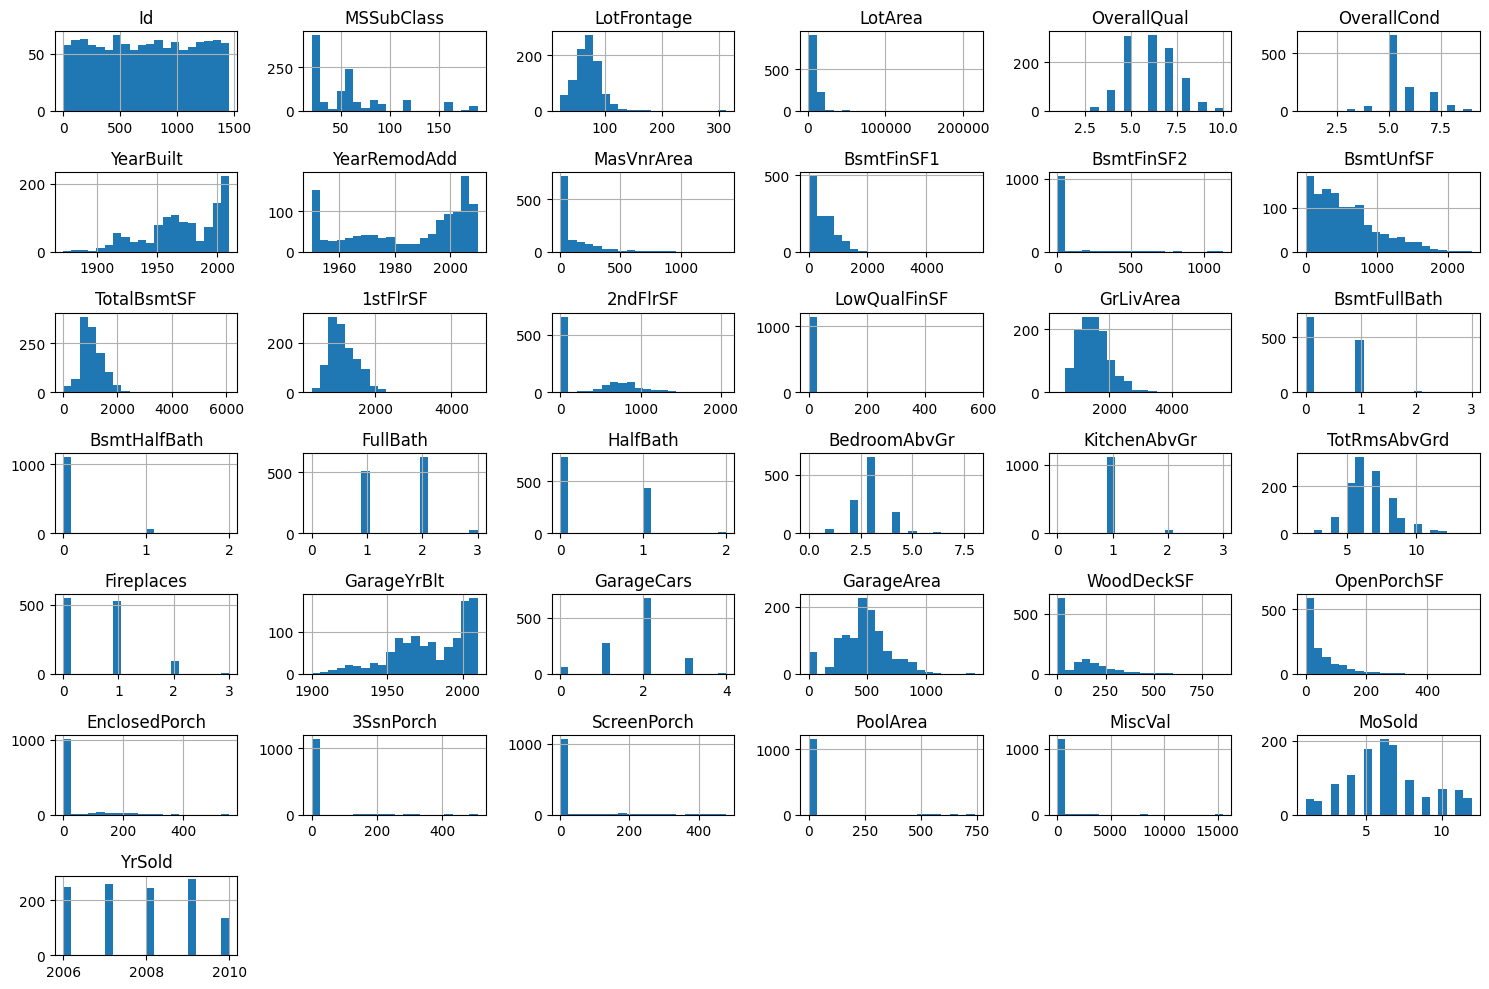

In [16]:
X_train[num_cols].describe()

plt.figure(figsize=(15, 10))
X_train[num_cols].hist(bins=20, figsize=(15, 10))
plt.tight_layout()
plt.show()

In [17]:
cols_with_missing = missing_info.index

cat_cols = [col for col in cols_with_missing if df[col].dtype == 'object']
num_cols = [col for col in cols_with_missing if df[col].dtype != 'object']

print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")
print(f"Numerical columns ({len(num_cols)}): {num_cols}")

Categorical columns (15): ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtFinType2', 'BsmtExposure', 'BsmtCond', 'BsmtFinType1', 'BsmtQual']
Numerical columns (3): ['LotFrontage', 'GarageYrBlt', 'MasVnrArea']


In [18]:
collumns_to_fill_none = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu', 
                         'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtFinType2', 
                         'BsmtExposure', 'BsmtCond', 'BsmtFinType1', 'BsmtQual'
                   ]

for col in collumns_to_fill_none:
    X_train[col] = X_train[col].fillna("None")
    X_test[col]=X_test[col].fillna("None")

In [19]:
X_train['GarageYrBlt'] = X_train['GarageYrBlt'].fillna(0)
X_test['GarageYrBlt'] = X_test['GarageYrBlt'].fillna(0)
X_train['MasVnrArea'] = X_train['MasVnrArea'].fillna(0)
X_test['MasVnrArea'] = X_test['MasVnrArea'].fillna(0)

train_median = X_train['LotFrontage'].median()
X_train['LotFrontage'] = X_train['LotFrontage'].fillna(train_median)

#test_median = X_test['LotFrontage'].median()
X_test['LotFrontage'] = X_test['LotFrontage'].fillna(train_median)

X_train['Electrical'] = X_train['Electrical'].fillna(X_train['Electrical'].mode()[0])

In [20]:
X_train.isnull().sum().sort_values(ascending=False)


Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MiscVal          0
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
Length: 80, dtype: int64

In [21]:
X_test.isnull().sum().sort_values(ascending=False)


Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MiscVal          0
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
Length: 80, dtype: int64

# Feature Engineering

outliers

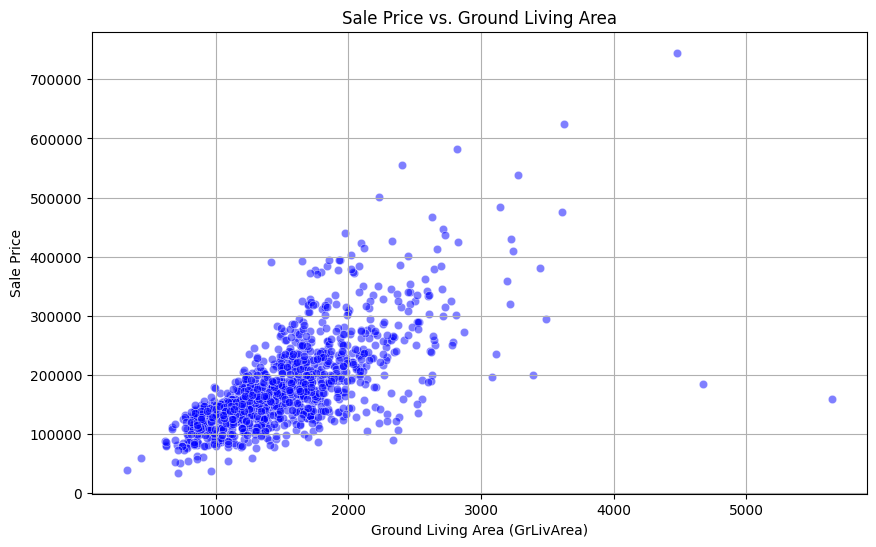

In [22]:
plt.figure(figsize=(10, 6))

sns.scatterplot(x=X_train['GrLivArea'], y=y_train, color='blue', alpha=0.5)

plt.title('Sale Price vs. Ground Living Area')
plt.xlabel('Ground Living Area (GrLivArea)')
plt.ylabel('Sale Price')
plt.grid(True)
plt.savefig("outlier_analysis.png")
plt.show()

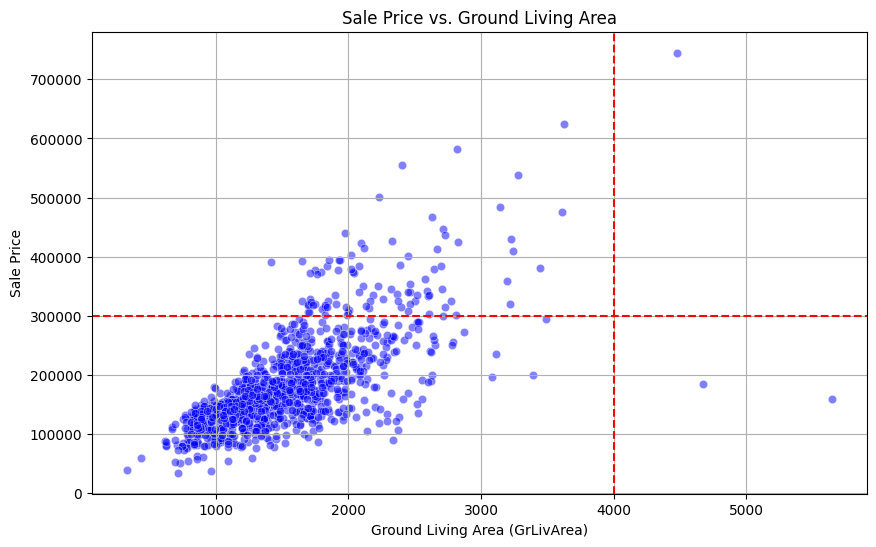

In [23]:
plt.figure(figsize=(10, 6))

sns.scatterplot(x=X_train['GrLivArea'], y=y_train, color='blue', alpha=0.5)

plt.axvline(x=4000, color='red', linestyle='--')
plt.axhline(y=300000, color='red', linestyle='--')

plt.title('Sale Price vs. Ground Living Area')
plt.xlabel('Ground Living Area (GrLivArea)')
plt.ylabel('Sale Price')
plt.grid(True)
plt.savefig("outlier_analysis.png")
plt.show()

In [24]:
train_idx = X_train[X_train['GrLivArea'] < 4000].index
X_train = X_train.loc[train_idx]
y_train = y_train.loc[train_idx]

In [25]:
X_train_fewoutliers = X_train;
y_train_fewoutliers= y_train;

Encoding

In [26]:
#label encoding
quality_map = {
    'Ex': 5,
    'Gd': 4,
    'TA': 3,
    'Fa': 2,
    'Po': 1,
    'Na': 0,
    'None': 0
}
ordinal_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 
                'HeatingQC', 'KitchenQual', 'FireplaceQu', 
                'GarageQual', 'GarageCond', 'PoolQC']


for col in ordinal_cols:
    X_train[col] = X_train[col].map(quality_map)
    X_test[col]=X_test[col].map(quality_map)


In [27]:
#one hot encoding
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [28]:
X_train.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
254,255,20,70.0,8400,5,6,1957,1957,0.0,3,...,False,False,False,True,False,False,False,False,True,False
1066,1067,60,59.0,7837,6,7,1993,1994,0.0,4,...,False,False,False,True,False,False,False,False,True,False
638,639,30,67.0,8777,5,7,1910,1950,0.0,3,...,False,False,False,True,False,False,False,False,True,False
799,800,50,60.0,7200,5,7,1937,1950,252.0,3,...,False,False,False,True,False,False,False,False,True,False
380,381,50,50.0,5000,5,6,1924,1950,0.0,3,...,False,False,False,True,False,False,False,False,True,False


In [29]:
X_train_v1=X_train
X_test_v1 = X_test

In [30]:
X_train['TotalSF'] = X_train['TotalBsmtSF'] + X_train['1stFlrSF'] + X_train['2ndFlrSF']
X_test['TotalSF'] = X_test['TotalBsmtSF'] + X_test['1stFlrSF'] + X_test['2ndFlrSF']


X_train['RemodAge'] = X_train['YrSold'] - X_train['YearRemodAdd']
X_test['RemodAge'] = X_test['YrSold'] - X_test['YearRemodAdd']

X_train['TotalBath'] = (X_train['FullBath'] + (0.5 * X_train['HalfBath']) +
                        X_train['BsmtFullBath'] + (0.5 * X_train['BsmtHalfBath']))
X_test['TotalBath'] = (X_test['FullBath'] + (0.5 * X_test['HalfBath']) +
                       X_test['BsmtFullBath'] + (0.5 * X_test['BsmtHalfBath']))


X_train['HouseAge'] = X_train['YrSold'] - X_train['YearBuilt']
X_test['HouseAge'] = X_test['YrSold'] - X_test['YearBuilt']


In [31]:
X_train.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,...,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,TotalSF,RemodAge,TotalBath,HouseAge
254,255,20,70.0,8400,5,6,1957,1957,0.0,3,...,False,False,False,False,True,False,2628,53,2.0,53
1066,1067,60,59.0,7837,6,7,1993,1994,0.0,4,...,False,False,False,False,True,False,2370,15,2.5,16
638,639,30,67.0,8777,5,7,1910,1950,0.0,3,...,False,False,False,False,True,False,1592,58,1.0,98
799,800,50,60.0,7200,5,7,1937,1950,252.0,3,...,False,False,False,False,True,False,2499,57,2.5,70
380,381,50,50.0,5000,5,6,1924,1950,0.0,3,...,False,False,False,False,True,False,2717,60,2.0,86


# Feature Selection

In [32]:
temp_df = X_train.copy()
temp_df['SalePrice_log'] = y_train_log


correlations = temp_df.corr(numeric_only=True)['SalePrice_log'].abs().sort_values(ascending=False)

threshold = 0.1
selected_features = correlations[correlations > threshold].index.tolist()


if 'SalePrice_log' in selected_features:
    selected_features.remove('SalePrice_log')

X_train_v2 = X_train[selected_features]
X_test_v2 = X_test[selected_features]

print(f"შერჩეული სვეტების რაოდენობა: {len(selected_features)}")

შერჩეული სვეტების რაოდენობა: 130


In [33]:
X_train_v2.head()

,TotalSF,OverallQual,GrLivArea,GarageCars,KitchenQual,ExterQual,GarageArea,TotalBath,TotalBsmtSF,BsmtQual,...,Exterior2nd_AsbShng,HouseStyle_1.5Unf,Exterior2nd_CmentBd,BldgType_Duplex,SaleCondition_Normal,BsmtFinType2_Unf,MSZoning_C (all),Condition1_Norm,BldgType_Twnhs,SaleType_COD
254,2628,5,1314,1,3,3,294,2.0,1314,3,...,False,False,False,False,True,True,False,True,False,False
1066,2370,6,1571,2,3,4,380,2.5,799,4,...,False,False,False,False,True,True,False,True,False,False
638,1592,5,796,0,3,3,0,1.0,796,2,...,False,False,False,False,True,True,False,False,False,False
799,2499,5,1768,1,4,3,240,2.5,731,4,...,False,False,False,False,True,True,False,False,False,False
380,2717,5,1691,1,4,3,308,2.0,1026,3,...,False,False,False,False,True,True,False,True,False,False


In [34]:
temp_df = X_train.copy()
temp_df['SalePrice_log'] = y_train_log


correlations = temp_df.corr(numeric_only=True)['SalePrice_log'].abs().sort_values(ascending=False)

threshold = 0.05
selected_features = correlations[correlations > threshold].index.tolist()

if 'SalePrice_log' in selected_features:
    selected_features.remove('SalePrice_log')


X_train_v3 = X_train[selected_features]
X_test_v3 = X_test[selected_features]

print(f"შერჩეული სვეტების რაოდენობა: {len(selected_features)}")

შერჩეული სვეტების რაოდენობა: 174


In [35]:
temp_df = X_train.copy()
temp_df['SalePrice_log'] = y_train_log


correlations = temp_df.corr(numeric_only=True)['SalePrice_log'].abs().sort_values(ascending=False)

threshold = 0.2
selected_features = correlations[correlations > threshold].index.tolist()


if 'SalePrice_log' in selected_features:
    selected_features.remove('SalePrice_log')

# საბოლოო დატასეტები
X_train_v4 = X_train[selected_features]
X_test_v4 = X_test[selected_features]

print(f"შერჩეული სვეტების რაოდენობა: {len(selected_features)}")

შერჩეული სვეტების რაოდენობა: 74


In [36]:
temp_df = X_train.copy()
temp_df['SalePrice_log'] = y_train_log


correlations = temp_df.corr(numeric_only=True)['SalePrice_log'].abs().sort_values(ascending=False)

threshold = 0.085
selected_features = correlations[correlations > threshold].index.tolist()


if 'SalePrice_log' in selected_features:
    selected_features.remove('SalePrice_log')

X_train_v5 = X_train[selected_features]
X_test_v5 = X_test[selected_features]

print(f"შერჩეული სვეტების რაოდენობა: {len(selected_features)}")

შერჩეული სვეტების რაოდენობა: 141


In [37]:
X_train_v5.shape


(1165, 141)

In [38]:
X_train.shape

(1165, 264)

In [39]:
X_train.shape

(1165, 264)

In [40]:
# X_train_v2 = X_train_v1
# X_test_v2 = X_test_v1

In [41]:
# cols_to_drop = ['PoolQC', 'Alley', 'MiscFeature']

# X_train_v2 = X_train_v1.drop(columns=cols_to_drop)
# X_test_v2 = X_test_v1.drop(columns=cols_to_drop)

In [46]:
X_train_log = X_train.copy()
X_test_log = X_test.copy()
X_train_log = np.log1p(X_train_log)
X_test_log = np.log1p(X_test_log)

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_log)

X_test_scaled = scaler.transform(X_test_log)

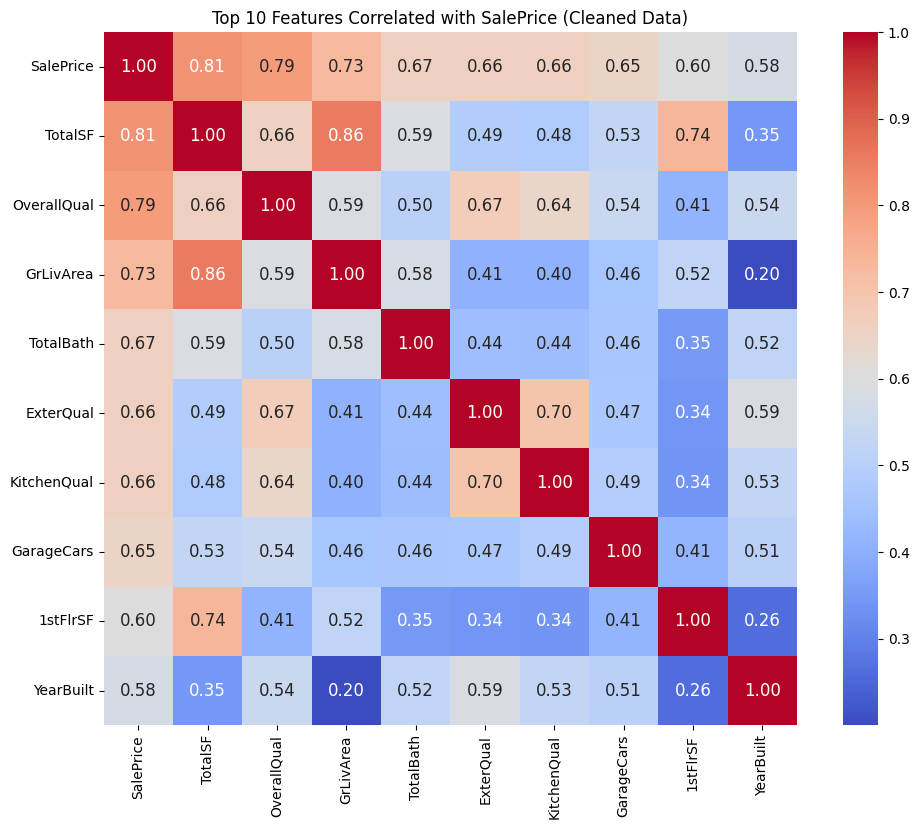

In [48]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


X_df = pd.DataFrame(X_train_scaled, columns=X_train_log.columns)

y_matched = y_train_log.loc[X_train_log.index]
X_df['SalePrice'] = y_matched.values

corrmat = X_df.corr()

#  ტოპ 10 სვეტის ამოღება
k = 10 
cols = corrmat.nlargest(k, 'SalePrice')['SalePrice'].index
cm = np.corrcoef(X_df[cols].values.T)

plt.figure(figsize=(12, 9))
sns.heatmap(cm, annot=True, square=True, fmt='.2f', 
            yticklabels=cols.values, xticklabels=cols.values,
            cmap="coolwarm", annot_kws={'size': 12})

plt.title("Top 10 Features Correlated with SalePrice (Cleaned Data)")
plt.show()

In [49]:
top_features = ['TotalSF', 'OverallQual', 'GrLivArea', 'TotalBath', 'ExterQual', 
                'KitchenQual', 'GarageCars', '1stFlrSF', 'YearBuilt']

# დავტოვოთ მხოლოდ ეს სვეტები (SalePrice-ის გარეშე)
X_train_top = X_train[top_features]
X_test_top = X_test[top_features]



In [51]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import ElasticNet

estimator = ElasticNet(alpha=0.0001, l1_ratio=0.5, max_iter=10000)
selector = RFE(estimator, n_features_to_select=70, step=5)
y_train_log = y_train_log.loc[X_train_log.index]
# მოვარგოთ დასკალირებულ მონაცემებს
selector = selector.fit(X_train_scaled, y_train_log)

# შევქმნათ ახალი ცვლადები, სადაც მხოლოდ შერჩეული სვეტები იქნება
X_train_final = selector.transform(X_train_scaled)
X_test_final = selector.transform(X_test_scaled)

print(f"Feature Selection დასრულდა. დარჩა {X_train_final.shape[1]} საუკეთესო სვეტი.")

Feature Selection დასრულდა. დარჩა 70 საუკეთესო სვეტი.


# Training


In [52]:
mlflow.set_experiment("House_Prices")

<Experiment: artifact_location='mlflow-artifacts:/3b7c6933d00649ae9db5abd921868fea', creation_time=1775547554507, experiment_id='1', last_update_time=1775750385492, lifecycle_stage='active', name='House_Prices', tags={'mlflow.experimentKind': 'custom_model_development'}, trace_location=None, workspace='default'>

In [53]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import mlflow
import mlflow.sklearn

In [ ]:
# num_features = X_train_v1.select_dtypes(include=[np.number]).columns


# X_train_log = X_train_v1.copy()
# X_test_log = X_test_v1.copy()

# X_train_log[num_features] = np.log1p(X_train_log[num_features])
# X_test_log[num_features] = np.log1p(X_test_log[num_features])

# run_name = "Linear_Regression_Baseline"

# with mlflow.start_run(run_name=run_name):
#     mlflow.set_tag("details", "cleaning + log target + outlier removal (GrLivArea<4000)")
#     mlflow.log_param("model_type",        "LinearRegression")
#     mlflow.log_param("target_transform",  "log1p")
#     mlflow.log_param("outlier_threshold", 4000)
#     mlflow.log_param("features_count",    X_train.shape[1])

#     model = LinearRegression()
#     model.fit(X_train_log, y_train_log)

#     # 3. პროგნოზირება (ლოგარითმულ სკალაში)
#     y_pred_log = model.predict(X_test_log)
    
#     # 4. პროგნოზების დაბრუნება ორიგინალ ფასებში
#     y_pred_orig = np.expm1(y_pred_log)
    
#     # 5. რეალური მნიშვნელობები ლოგარითმულ სკალაში (ტესტისთვის)
#     y_test_log = np.log1p(y_test)

#     # --- მეტრიკები ---
#     log_rmse = np.sqrt(mean_squared_error(y_test_log, y_pred_log))
#     rmse_orig = np.sqrt(mean_squared_error(y_test, y_pred_orig))
#     mae_orig = mean_absolute_error(y_test, y_pred_orig)
#     r2 = r2_score(y_test, y_pred_orig)
    
#     # MAPE (საშუალო პროცენტული ცდომილება)
#     mape = np.mean(np.abs((y_test - y_pred_orig) / y_test)) * 100

#     # 6. დალოგვა
#     mlflow.log_metric("log_rmse", log_rmse)
#     mlflow.log_metric("rmse_original", rmse_orig)
#     mlflow.log_metric("mae_original", mae_orig)
#     mlflow.log_metric("r2_score", r2)
#     mlflow.log_metric("mape_percent", mape)

#     print(f" Run '{run_name}' finished!")
#     print(f"   Log-RMSE: {log_rmse:.4f}")
#     print(f"   MAE: ${mae_orig:.2f}")
#     print(f"   R2 Score: {r2:.4f}")

#     # 7. მოდელის შენახვა
#     mlflow.sklearn.log_model(model, "linear_model_log")

In [ ]:
# num_features = X_train_v2.select_dtypes(include=[np.number]).columns


# X_train_log = X_train_v2.copy()
# X_test_log = X_test_v2.copy()

# X_train_log[num_features] = np.log1p(X_train_log[num_features])
# X_test_log[num_features] = np.log1p(X_test_log[num_features])
# run_name = "Linear_Regression_With_feature_engineering_and_selection"

# with mlflow.start_run(run_name=run_name):
#     mlflow.set_tag("details", "cleaning + log target + outlier removal (GrLivArea<4000) +  new feature + removed 130 features")
#     mlflow.log_param("model_type",        "LinearRegression")
#     mlflow.log_param("target_transform",  "log1p")
#     mlflow.log_param("outlier_threshold", 4000)
#     mlflow.log_param("correlation_threshold", 0.1)
#     mlflow.log_param("features_count",    X_train_v2.shape[1])

#     model = LinearRegression()
#     model.fit(X_train_log, y_train_log)

#     # 3. პროგნოზირება (ლოგარითმულ სკალაში)
#     y_pred_log = model.predict(X_test_log)
    
#     # 4. პროგნოზების დაბრუნება ორიგინალ ფასებში
#     y_pred_orig = np.expm1(y_pred_log)
    
#     # 5. რეალური მნიშვნელობები ლოგარითმულ სკალაში (ტესტისთვის)
#     y_test_log = np.log1p(y_test)

#     # --- მეტრიკები ---
#     log_rmse = np.sqrt(mean_squared_error(y_test_log, y_pred_log))
#     rmse_orig = np.sqrt(mean_squared_error(y_test, y_pred_orig))
#     mae_orig = mean_absolute_error(y_test, y_pred_orig)
#     r2 = r2_score(y_test, y_pred_orig)
    
#     # MAPE (საშუალო პროცენტული ცდომილება)
#     mape = np.mean(np.abs((y_test - y_pred_orig) / y_test)) * 100

#     mlflow.log_metric("log_rmse", log_rmse)
#     mlflow.log_metric("rmse_original", rmse_orig)
#     mlflow.log_metric("mae_original", mae_orig)
#     mlflow.log_metric("r2_score", r2)
#     mlflow.log_metric("mape_percent", mape)

#     print(f" Run '{run_name}' finished!")
#     print(f"   Log-RMSE: {log_rmse:.4f}")
#     print(f"   MAE: ${mae_orig:.2f}")
#     print(f"   R2 Score: {r2:.4f}")


#     mlflow.sklearn.log_model(model, "linear_model_log")

In [ ]:
# num_features = X_train_v3.select_dtypes(include=[np.number]).columns


# X_train_log = X_train_v3.copy()
# X_test_log = X_test_v3.copy()

# X_train_log[num_features] = np.log1p(X_train_log[num_features])
# X_test_log[num_features] = np.log1p(X_test_log[num_features])
# run_name = "Linear_Regression_With_different_threshold"

# with mlflow.start_run(run_name=run_name):
#     mlflow.set_tag("details", "cleaning + log target + outlier removal (GrLivArea<4000) +  new feature + removed 174 features")
#     mlflow.log_param("model_type",        "LinearRegression")
#     mlflow.log_param("target_transform",  "log1p")
#     mlflow.log_param("outlier_threshold", 4000)
#     mlflow.log_param("correlation_threshold", 0.2)
#     mlflow.log_param("features_count",    X_train_v3.shape[1])

#     model = LinearRegression()
#     model.fit(X_train_log, y_train_log)

#     # 3. პროგნოზირება (ლოგარითმულ სკალაში)
#     y_pred_log = model.predict(X_test_log)
    
#     # 4. პროგნოზების დაბრუნება ორიგინალ ფასებში
#     y_pred_orig = np.expm1(y_pred_log)
    
#     # 5. რეალური მნიშვნელობები ლოგარითმულ სკალაში (ტესტისთვის)
#     y_test_log = np.log1p(y_test)

#     # --- მეტრიკები ---
#     log_rmse = np.sqrt(mean_squared_error(y_test_log, y_pred_log))
#     rmse_orig = np.sqrt(mean_squared_error(y_test, y_pred_orig))
#     mae_orig = mean_absolute_error(y_test, y_pred_orig)
#     r2 = r2_score(y_test, y_pred_orig)
    
#     # MAPE (საშუალო პროცენტული ცდომილება)
#     mape = np.mean(np.abs((y_test - y_pred_orig) / y_test)) * 100

#     mlflow.log_metric("log_rmse", log_rmse)
#     mlflow.log_metric("rmse_original", rmse_orig)
#     mlflow.log_metric("mae_original", mae_orig)
#     mlflow.log_metric("r2_score", r2)
#     mlflow.log_metric("mape_percent", mape)

#     print(f" Run '{run_name}' finished!")
#     print(f"   Log-RMSE: {log_rmse:.4f}")
#     print(f"   MAE: ${mae_orig:.2f}")
#     print(f"   R2 Score: {r2:.4f}")


#     mlflow.sklearn.log_model(model, "linear_model_log")

In [ ]:
# num_features = X_train_v4.select_dtypes(include=[np.number]).columns


# X_train_log = X_train_v4.copy()
# X_test_log = X_test_v4.copy()

# X_train_log[num_features] = np.log1p(X_train_log[num_features])
# X_test_log[num_features] = np.log1p(X_test_log[num_features])
# run_name = "Linear_Regression_With_different_threshold"

# with mlflow.start_run(run_name=run_name):
#     mlflow.set_tag("details", "different threshold 0.2")
#     mlflow.log_param("model_type",        "LinearRegression")
#     mlflow.log_param("target_transform",  "log1p")
#     mlflow.log_param("outlier_threshold", 4000)
#     mlflow.log_param("correlation_threshold", 0.2)
#     mlflow.log_param("features_count",    X_train_v4.shape[1])

#     model = LinearRegression()
#     model.fit(X_train_log, y_train_log)

#     # 3. პროგნოზირება (ლოგარითმულ სკალაში)
#     y_pred_log = model.predict(X_test_log)
    
#     # 4. პროგნოზების დაბრუნება ორიგინალ ფასებში
#     y_pred_orig = np.expm1(y_pred_log)
    
#     # 5. რეალური მნიშვნელობები ლოგარითმულ სკალაში (ტესტისთვის)
#     y_test_log = np.log1p(y_test)

#     # --- მეტრიკები ---
#     log_rmse = np.sqrt(mean_squared_error(y_test_log, y_pred_log))
#     rmse_orig = np.sqrt(mean_squared_error(y_test, y_pred_orig))
#     mae_orig = mean_absolute_error(y_test, y_pred_orig)
#     r2 = r2_score(y_test, y_pred_orig)
    
#     # MAPE (საშუალო პროცენტული ცდომილება)
#     mape = np.mean(np.abs((y_test - y_pred_orig) / y_test)) * 100

#     mlflow.log_metric("log_rmse", log_rmse)
#     mlflow.log_metric("rmse_original", rmse_orig)
#     mlflow.log_metric("mae_original", mae_orig)
#     mlflow.log_metric("r2_score", r2)
#     mlflow.log_metric("mape_percent", mape)

#     print(f" Run '{run_name}' finished!")
#     print(f"   Log-RMSE: {log_rmse:.4f}")
#     print(f"   MAE: ${mae_orig:.2f}")
#     print(f"   R2 Score: {r2:.4f}")


#     mlflow.sklearn.log_model(model, "linear_model_log")

with top 10

In [ ]:
num_features = X_train_top.select_dtypes(include=[np.number]).columns

X_train_log = X_train_top.copy()
X_test_log = X_test_top.copy()

X_train_log[num_features] = np.log1p(X_train_log[num_features])
X_test_log[num_features] = np.log1p(X_test_log[num_features])

y_train_log = y_train_log.loc[X_train_log.index]
run_name = "Linear_Regression_10Top"

with mlflow.start_run(run_name=run_name):
    mlflow.set_tag("details", "10top features ")
    mlflow.log_param("model_type",        "LinearRegression")
    mlflow.log_param("target_transform",  "log1p")
    mlflow.log_param("outlier_threshold", 4000)
    mlflow.log_param("features_count",    X_train_top.shape[1])

    model = LinearRegression()
    model.fit(X_train_log, y_train_log)

    y_pred_log = model.predict(X_test_log)
    y_pred_orig = np.expm1(y_pred_log)
    y_test_log = np.log1p(y_test)

    log_rmse = np.sqrt(mean_squared_error(y_test_log, y_pred_log))
    rmse_orig = np.sqrt(mean_squared_error(y_test, y_pred_orig))
    mae_orig = mean_absolute_error(y_test, y_pred_orig)
    r2 = r2_score(y_test, y_pred_orig)
    mape = np.mean(np.abs((y_test - y_pred_orig) / y_test)) * 100

    mlflow.log_metric("log_rmse", log_rmse)
    mlflow.log_metric("rmse_original", rmse_orig)
    mlflow.log_metric("mae_original", mae_orig)
    mlflow.log_metric("r2_score", r2)
    mlflow.log_metric("mape_percent", mape)

    print(f" Run '{run_name}' finished!")
    print(f"   Log-RMSE: {log_rmse:.4f}")
    print(f"   MAE: ${mae_orig:.2f}")
    print(f"   R2 Score: {r2:.4f}")

    import matplotlib.pyplot as plt
    import seaborn as sns
    
    plt.figure(figsize=(8, 8))
    # ვხატავთ წერტილებს: X-ღერძზე რეალური ფასები, Y-ღერძზე პროგნოზი
    plt.scatter(y_test, y_pred_orig, alpha=0.5, color='royalblue')
    
    # ვავლებთ იდეალურ წითელ ხაზს (თუ წერტილი ამ ხაზზეა, ესეიგი მოდელმა 100%-ით ზუსტად იწინასწარმეტყველა)
    max_val = max(y_test.max(), y_pred_orig.max())
    min_val = min(y_test.min(), y_pred_orig.min())
    plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)
    
    plt.xlabel("რეალური ფასები (Actual Prices)")
    plt.ylabel("პროგნოზირებული ფასები (Predicted Prices)")
    plt.title("მოდელის სიზუსტე: რეალური VS პროგნოზი")
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.show()


    mlflow.sklearn.log_model(model, "linear_model_log")
    

with rfe with diff top (80,90,110)

In [ ]:
import mlflow
import numpy as np
from sklearn.metrics import mean_squared_error
import joblib
run_name = "ElasticNet_RFE_Selected_70"

with mlflow.start_run(run_name=run_name):
    # პარამეტრების დალოგვა
    mlflow.log_param("model_type", "ElasticNet")
    mlflow.log_param("alpha", 0.0001)
    mlflow.log_param("features_count", 70)
    mlflow.log_param("rfe_used", True)

    # მოდელის შექმნა და სწავლება შერჩეულ სვეტებზე
    model = ElasticNet(alpha=0.0001, l1_ratio=0.5, max_iter=10000)
    model.fit(X_train_final, y_train_log)

    # პროგნოზი და მეტრიკები
    y_pred_log = model.predict(X_test_final)
    log_rmse = np.sqrt(mean_squared_error(y_test_log, y_pred_log))
    
    # ტრეინინგის RMSE (Overfitting-ის შესამოწმებლად)
    y_train_pred = model.predict(X_train_final)
    train_rmse = np.sqrt(mean_squared_error(y_train_log, y_train_pred))

    mlflow.log_metric("log_rmse", log_rmse)
    mlflow.log_metric("train_log_rmse", train_rmse)
    
    mlflow.sklearn.log_model(model, "model")
    joblib.dump(selector, "selector.pkl")
    mlflow.log_artifact("selector.pkl")
    print(f"RFE მოდელის შედეგი:")
    print(f"Test RMSE: {log_rmse:.4f}")
    print(f"Train RMSE: {train_rmse:.4f}")

In [ ]:
# num_features = X_train_v5.select_dtypes(include=[np.number]).columns

# X_train_log = X_train_v5.copy()
# X_test_log = X_test_v5.copy()

# X_train_log[num_features] = np.log1p(X_train_log[num_features])
# X_test_log[num_features] = np.log1p(X_test_log[num_features])

# y_train_log = y_train_log.loc[X_train_log.index]
# run_name = "Linear_Regression_best_model"

# with mlflow.start_run(run_name=run_name):
#     mlflow.set_tag("details", "different threshold 0.085 ")
#     mlflow.log_param("model_type",        "LinearRegression")
#     mlflow.log_param("target_transform",  "log1p")
#     mlflow.log_param("outlier_threshold", 4000)
#     mlflow.log_param("correlation_threshold", 0.085)
#     mlflow.log_param("features_count",    X_train_v5.shape[1])

#     model = LinearRegression()
#     model.fit(X_train_log, y_train_log)

#     y_pred_log = model.predict(X_test_log)
#     y_pred_orig = np.expm1(y_pred_log)
#     y_test_log = np.log1p(y_test)

#     log_rmse = np.sqrt(mean_squared_error(y_test_log, y_pred_log))
#     rmse_orig = np.sqrt(mean_squared_error(y_test, y_pred_orig))
#     mae_orig = mean_absolute_error(y_test, y_pred_orig)
#     r2 = r2_score(y_test, y_pred_orig)
#     mape = np.mean(np.abs((y_test - y_pred_orig) / y_test)) * 100

#     mlflow.log_metric("log_rmse", log_rmse)
#     mlflow.log_metric("rmse_original", rmse_orig)
#     mlflow.log_metric("mae_original", mae_orig)
#     mlflow.log_metric("r2_score", r2)
#     mlflow.log_metric("mape_percent", mape)

#     print(f" Run '{run_name}' finished!")
#     print(f"   Log-RMSE: {log_rmse:.4f}")
#     print(f"   MAE: ${mae_orig:.2f}")
#     print(f"   R2 Score: {r2:.4f}")

#     import matplotlib.pyplot as plt
#     import seaborn as sns
    
#     plt.figure(figsize=(8, 8))
#     # ვხატავთ წერტილებს: X-ღერძზე რეალური ფასები, Y-ღერძზე პროგნოზი
#     plt.scatter(y_test, y_pred_orig, alpha=0.5, color='royalblue')
    
#     # ვავლებთ იდეალურ წითელ ხაზს (თუ წერტილი ამ ხაზზეა, ესეიგი მოდელმა 100%-ით ზუსტად იწინასწარმეტყველა)
#     max_val = max(y_test.max(), y_pred_orig.max())
#     min_val = min(y_test.min(), y_pred_orig.min())
#     plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)
    
#     plt.xlabel("რეალური ფასები (Actual Prices)")
#     plt.ylabel("პროგნოზირებული ფასები (Predicted Prices)")
#     plt.title("მოდელის სიზუსტე: რეალური VS პროგნოზი")
#     plt.grid(True, linestyle=':', alpha=0.7)
#     plt.show()


#     mlflow.sklearn.log_model(model, "linear_model_log")
    

In [54]:
num_features = X_train_v5.select_dtypes(include=[np.number]).columns

X_train_log = X_train_v5.copy()
X_test_log = X_test_v5.copy()

X_train_log[num_features] = np.log1p(X_train_log[num_features])
X_test_log[num_features] = np.log1p(X_test_log[num_features])

y_train_log = y_train_log.loc[X_train_log.index]
run_name = "Linear_Regression_With_different_threshold"

model = LinearRegression()
model.fit(X_train_log, y_train_log)

y_pred_log = model.predict(X_test_log)
y_pred_orig = np.expm1(y_pred_log)
y_test_log = np.log1p(y_test)

y_pred_log1= model.predict(X_train_log)


log_rmse = np.sqrt(mean_squared_error(y_test_log, y_pred_log))
log_rmse_1 = np.sqrt(mean_squared_error(y_train_log, y_pred_log1))

print(f" Run '{run_name}' finished!")
print(f"   Log-RMSE - test: {log_rmse:.4f}")
print(f"   Log-RMSE - train: {log_rmse_1:.4f}")



 Run 'Linear_Regression_With_different_threshold' finished!
   Log-RMSE - test: 0.1189
   Log-RMSE - train: 0.1007


In [55]:
    from sklearn.linear_model import Ridge, Lasso, ElasticNet
    from sklearn.model_selection import cross_val_score
  

    models = {
        "Ridge (alpha=10)": Ridge(alpha=10),
        "Lasso (alpha=0.0005)": Lasso(alpha=0.0005),
        "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.5)
    }
    
    results = []
    
    
    for name, model in models.items():
        scores = cross_val_score(model, X_train_log, y_train_log, 
                                 scoring='neg_mean_squared_error', cv=5)
        
        rmse_scores = np.sqrt(-scores)
        
        results.append({
            "Model": name,
            "Mean RMSE": rmse_scores.mean(),
            "Std Dev": rmse_scores.std() 
        })
    

    results_df = pd.DataFrame(results).sort_values(by="Mean RMSE")
    print("შედარების შედეგები:")
    print(results_df)

შედარების შედეგები:
                  Model  Mean RMSE   Std Dev
2            ElasticNet   0.120841  0.006558
1  Lasso (alpha=0.0005)   0.120966  0.006409
0      Ridge (alpha=10)   0.121300  0.006974


alpha parametrit

In [ ]:
# run_name = "ElasticNet_Best_Alpha_0.0001"

# with mlflow.start_run(run_name=run_name):
#     mlflow.log_param("model_type", "ElasticNet")
#     mlflow.log_param("alpha", 0.0001)
#     mlflow.log_param("l1_ratio", 0.5)
    

#     model = ElasticNet(alpha=0.0001, l1_ratio=0.5, random_state=42)
#     model.fit(X_train_log, y_train_log)
    
#     # 3. მეტრიკების დათვლა და დალოგვა
#     y_pred_log = model.predict(X_test_log)
#     log_rmse = np.sqrt(mean_squared_error(y_test_log, y_pred_log))
#     log_rmse_1 = np.sqrt(mean_squared_error(y_train_log, y_pred_log1))
#     mlflow.log_metric("log_rmse", log_rmse)

    
#     # 4. მოდელის შენახვა
#     mlflow.sklearn.log_model(model, "model")
    
#     print(f"მოდელი დალოგილია Alpha=0.0001-ით. RMSE: {log_rmse:.4f}")
#     print(f"   Log-RMSE - train: {log_rmse_1:.4f}")


Best model:

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.121e-02, tolerance: 1.758e-02
  model = cd_fast.enet_coordinate_descent(
2026/04/11 07:07:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/11 07:07:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


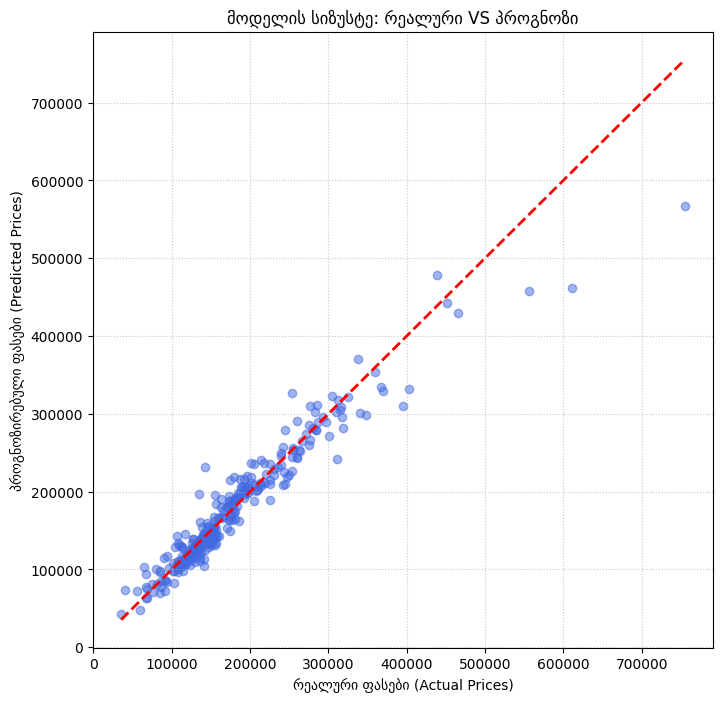

=RMSE (Test): 0.1172
 RMSE (Train): 0.1008
🏃 View run ElasticNet_FINAL at: https://dagshub.com/mkekn23/ML-assignment-1.mlflow/#/experiments/1/runs/06a9dc43fccc4585b37f4b8247bf4020
🧪 View experiment at: https://dagshub.com/mkekn23/ML-assignment-1.mlflow/#/experiments/1


In [59]:
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_log)
X_test_scaled = scaler.transform(X_test_log) 

run_name = "ElasticNet_FINAL"

with mlflow.start_run(run_name=run_name):
  
    params = {"model_type": "ElasticNet", "alpha": 0.0001, "l1_ratio": 0.5, "scaled": True}
    mlflow.log_params(params)
    
 
    model = ElasticNet(alpha=params["alpha"], l1_ratio=params["l1_ratio"])
    model.fit(X_train_scaled, y_train_log)

    y_test_pred = model.predict(X_test_scaled)
    y_train_pred = model.predict(X_train_scaled)
    
    test_rmse = np.sqrt(mean_squared_error(y_test_log, y_test_pred))
    train_rmse = np.sqrt(mean_squared_error(y_train_log, y_train_pred))

    y_pred_log = model.predict(X_test_scaled)
    
  
    y_pred_orig = np.expm1(y_pred_log)
    
    log_rmse = np.sqrt(mean_squared_error(y_test_log, y_pred_log))
    mae_orig = mean_absolute_error(y_test, y_pred_orig)
    r2 = r2_score(y_test, y_pred_orig)
   

    mlflow.log_metric("mae_original", mae_orig)
    mlflow.log_metric("r2_score", r2)
    
    mlflow.log_metric("log_rmse", test_rmse)
    mlflow.log_metric("train_rmse", train_rmse)
    
    mlflow.sklearn.log_model(model, "model")
    
    plt.figure(figsize=(8, 8))
    # ვხატავთ წერტილებს: X-ღერძზე რეალური ფასები, Y-ღერძზე პროგნოზი
    plt.scatter(y_test, y_pred_orig, alpha=0.5, color='royalblue')
    
    # ვავლებთ იდეალურ წითელ ხაზს (თუ წერტილი ამ ხაზზეა, ესეიგი მოდელმა 100%-ით ზუსტად იწინასწარმეტყველა)
    max_val = max(y_test.max(), y_pred_orig.max())
    min_val = min(y_test.min(), y_pred_orig.min())
    plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)
    
    plt.xlabel("რეალური ფასები (Actual Prices)")
    plt.ylabel("პროგნოზირებული ფასები (Predicted Prices)")
    plt.title("მოდელის სიზუსტე: რეალური VS პროგნოზი")
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.show()
    
    print(f"=RMSE (Test): {test_rmse:.4f}")
    print(f" RMSE (Train): {train_rmse:.4f}")

**Decition tree**

In [ ]:
# from sklearn.tree import DecisionTreeRegressor
# import matplotlib.pyplot as plt
# import pandas as pd
# import numpy as np
# import mlflow
# import mlflow.sklearn
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# max_depth = 12
# min_samples_leaf = 20
# tree_model = DecisionTreeRegressor(max_depth=max_depth, min_samples_leaf=min_samples_leaf, random_state=42)


# y_train_log_fixed = y_train_log.loc[X_train_v5.index]

# run_name = "Decision_Tree_Refined_v6"

# with mlflow.start_run(run_name=run_name):
#     mlflow.set_tag("details", "max_depth = 12")
#     mlflow.log_param("model_type", "Decision_Tree")
#     mlflow.log_param("features_count", X_train_v5.shape[1])
#     mlflow.log_param("max_depth", max_depth)
#     mlflow.log_param("min_samples_leaf", min_samples_leaf)

  
#     tree_model.fit(X_train_v5, y_train_log_fixed)
    
#     y_pred_log = tree_model.predict(X_test_v5)
#     y_pred_orig = np.expm1(y_pred_log)
    
#     log_rmse = np.sqrt(mean_squared_error(y_test_log, y_pred_log))
#     mae_orig = mean_absolute_error(y_test, y_pred_orig)
#     r2 = r2_score(y_test, y_pred_orig)
    

#     mlflow.log_metric("log_rmse", log_rmse)
#     mlflow.log_metric("mae_original", mae_orig)
#     mlflow.log_metric("r2_score", r2)

#     # --- FEATURE IMPORTANCE PLOT ---
#     plt.figure(figsize=(10, 6))
#     importances = pd.Series(tree_model.feature_importances_, index=X_train_v5.columns)
#     importances.nlargest(15).plot(kind='barh', color='skyblue')
#     plt.title("Top 15 Important Features (Decision Tree)")
#     plt.tight_layout()
#     plt.savefig("feature_importance_tree.png")
    
#     mlflow.log_artifact("feature_importance_tree.png")
#     mlflow.sklearn.log_model(tree_model, "decision_tree_model")
    
#     print(f" Run '{run_name}' finished!")
#     print(f"   Tree Depth: {tree_model.get_depth()}")
#     print(f"   Log-RMSE: {log_rmse:.4f}")
#     print(f"   R2 Score: {r2:.4f}")

In [ ]:
# from sklearn.tree import DecisionTreeRegressor
# from sklearn.metrics import mean_squared_error

# dt_model = DecisionTreeRegressor(
#     max_depth=5,             
#     min_samples_split=10,    
#     min_samples_leaf=10,
#     random_state=42
# )
# y_train_log = y_train_log.loc[X_train.index]
# dt_model.fit(X_train, y_train_log)


# train_preds = dt_model.predict(X_train)
# test_preds = dt_model.predict(X_test)

# test_rmse = np.sqrt(mean_squared_error(y_test_log, test_preds))
# train_rmse = np.sqrt(mean_squared_error(y_train_log, train_preds)) 


# print(f"Train RMSE: {train_rmse:.4f}")
# print(f"Test RMSE: {test_rmse:.4f}")

In [ ]:
# dt_model = DecisionTreeRegressor(
#     max_depth=5,              # 1. ვზღუდავთ ხის სიღრმეს (Overfitting-ის საწინააღმდეგოდ)
#     min_samples_split=10,     # 2. კვანძი არ გაიყოფა, თუ მასში 10-ზე ნაკლები ჩანაწერია
#     min_samples_leaf=5,       # 3. თითოეულ "ფოთოლში" (ბოლო კვანძში) მინიმუმ 5 სახლი მაინც უნდა იყოს
#     random_state=42
# )
# y_train_log_fixed = y_train_log.loc[X_train.index]

# run_name = "Decision_Tree_Refined_v8"

# with mlflow.start_run(run_name=run_name):
#     mlflow.set_tag("details", "max_depth = 5")
#     mlflow.log_param("model_type", "Decision_Tree")
#     mlflow.log_param("features_count", X_train.shape[1])
#     mlflow.log_param("max_depth", max_depth)
#     mlflow.log_param("min_samples_leaf", min_samples_leaf)

  
#     dt_model.fit(X_train, y_train_log_fixed)
    
#     y_pred_log = dt_model.predict(X_test)
#     y_pred_orig = np.expm1(y_pred_log)
    
#     log_rmse = np.sqrt(mean_squared_error(y_test_log, y_pred_log))
#     mae_orig = mean_absolute_error(y_test, y_pred_orig)
#     r2 = r2_score(y_test, y_pred_orig)
    

#     mlflow.log_metric("log_rmse", log_rmse)
#     mlflow.log_metric("mae_original", mae_orig)
#     mlflow.log_metric("r2_score", r2)

#     # --- FEATURE IMPORTANCE PLOT ---
#     plt.figure(figsize=(10, 6))
#     importances = pd.Series(tree_model.feature_importances_, index=X_train.columns)
#     importances.nlargest(15).plot(kind='barh', color='skyblue')
#     plt.title("Top 15 Important Features (Decision Tree)")
#     plt.tight_layout()
#     plt.savefig("feature_importance_tree.png")
    
#     mlflow.log_artifact("feature_importance_tree.png")
#     mlflow.sklearn.log_model(tree_model, "decision_tree_model")
    
#     print(f" Run '{run_name}' finished!")
#     print(f"   Tree Depth: {tree_model.get_depth()}")
#     print(f"   Log-RMSE: {log_rmse:.4f}")
#     print(f"   R2 Score: {r2:.4f}")

In [ ]:
# from sklearn.model_selection import GridSearchCV


# param_grid = {
#     'max_depth': [5, 8, 10, 12, 15],
#     'min_samples_split': [5, 10, 20],
#     'min_samples_leaf': [5, 10, 15, 20]
# }

# # ვაკეთებთ ძებნას 5-Fold Cross Validation-ით
# grid_search = GridSearchCV(
#     estimator=DecisionTreeRegressor(random_state=42),
#     param_grid=param_grid,
#     cv=5,
#     scoring='neg_root_mean_squared_error',
#     n_jobs=-1
# )

# grid_search.fit(X_train, y_train_log_fixed)

# print(f"საუკეთესო პარამეტრები: {grid_search.best_params_}")

# tree_model = grid_search.best_estimator_

# run_name = "Decision_Tree_GridSearch_Optimized"

# with mlflow.start_run(run_name=run_name):
#     mlflow.set_tag("details", "GridSearchCV for Decision Tree")
#     mlflow.log_param("model_type", "Decision_Tree")
#     mlflow.log_param("features_count", X_train.shape[1])
    
#    
#     mlflow.log_params(grid_search.best_params_)

#     
#     y_pred_log = tree_model.predict(X_test)
#     y_pred_orig = np.expm1(y_pred_log) # ვაბრუნებთ ორიგინალ ფასებში
    
#     
#     log_rmse = np.sqrt(mean_squared_error(y_test_log, y_pred_log))
#     mae_orig = mean_absolute_error(y_test, y_pred_orig)
#     r2 = r2_score(y_test, y_pred_orig)
    
#     
#     mlflow.log_metric("log_rmse", log_rmse)
#     mlflow.log_metric("mae_original", mae_orig)
#     mlflow.log_metric("r2_score", r2)

#     # --- FEATURE IMPORTANCE PLOT ---
#     plt.figure(figsize=(10, 6))
#     importances = pd.Series(tree_model.feature_importances_, index=X_train.columns)
#     importances.nlargest(15).plot(kind='barh', color='skyblue')
#     plt.title("Top 15 Important Features (Optimized Decision Tree)")
#     plt.tight_layout()
#     plt.savefig("feature_importance_tree_optimized.png")
    

#     mlflow.log_artifact("feature_importance_tree_optimized.png")
#     mlflow.sklearn.log_model(tree_model, "decision_tree_model_optimized")
    
#     
#     print(f" Run '{run_name}' finished!")
#     print(f"   Best Params Found: {grid_search.best_params_}")
#     print(f"   Log-RMSE: {log_rmse:.4f}")
#     print(f"   R2 Score: {r2:.4f}")

In [ ]:
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.model_selection import GridSearchCV

# # Random Forest-ის პარამეტრები
# param_grid_rf = {
#     'n_estimators': [100,200],   
#     'max_depth': [10, 15, None],   
#     'min_samples_split': [2, 5],     
#     'min_samples_leaf': [1, 2]
# }

# 
# grid_search_rf = GridSearchCV(
#     estimator=RandomForestRegressor(random_state=42),
#     param_grid=param_grid_rf,
#     cv=5,
#     scoring='neg_root_mean_squared_error',
#     n_jobs=2,
#     verbose=3
# )

# grid_search_rf.fit(X_train, y_train_log_fixed)

# print(f"საუკეთესო პარამეტრები: {grid_search_rf.best_params_}")
# best_rf_model = grid_search_rf.best_estimator_

# 
# y_pred_log_rf = best_rf_model.predict(X_test)

In [ ]:
# run_name = "Random_Forest_GridSearch_Optimized"

# with mlflow.start_run(run_name=run_name):
 
#     mlflow.set_tag("details", "GridSearchCV for Random Forest")
#     mlflow.log_param("model_type", "Random_Forest")
#     mlflow.log_param("features_count", X_train.shape[1])
    
 
#     mlflow.log_params(grid_search_rf.best_params_)


#     y_pred_orig_rf = np.expm1(y_pred_log_rf)
    
  
#     log_rmse = np.sqrt(mean_squared_error(y_test_log, y_pred_log_rf))
#     mae_orig = mean_absolute_error(y_test, y_pred_orig_rf)
#     r2 = r2_score(y_test, y_pred_orig_rf)
    
 
#     mlflow.log_metric("log_rmse", log_rmse)
#     mlflow.log_metric("mae_original", mae_orig)
#     mlflow.log_metric("r2_score", r2)

#     plt.figure(figsize=(10, 6))
#     importances = pd.Series(best_rf_model.feature_importances_, index=X_train.columns)
#     importances.nlargest(15).plot(kind='barh', color='lightgreen') # ფერი შევცვალე, რომ ხისგან განასხვავო
#     plt.title("Top 15 Important Features (Random Forest)")
#     plt.tight_layout()
#     plt.savefig("feature_importance_rf.png")
    
#     mlflow.log_artifact("feature_importance_rf.png")
#     mlflow.sklearn.log_model(best_rf_model, "random_forest_model_optimized")
    

#     print(f" Run '{run_name}' წარმატებით დასრულდა და შეინახა MLflow-ში!")
#     print(f"ტყის საუკეთესო პარამეტრები: {grid_search_rf.best_params_}")
#     print(f"Log-RMSE : {log_rmse:.4f}")
#     print(f"R2 Score: {r2:.4f}")

In [ ]:
# from sklearn.linear_model import Ridge
# from sklearn.model_selection import GridSearchCV
# import mlflow
# import mlflow.sklearn
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# # 1. Ridge Regression-ის პარამეტრები 
# # alpha ჯარიმის ძალა
# param_grid_ridge = {
#     'alpha': [0.1, 1.0, 10.0, 100.0, 200.0, 500.0]
# }

# # 2. ვაკეთებთ ძებნას (GridSearchCV)
# grid_search_ridge = GridSearchCV(
#     estimator=Ridge(random_state=42),
#     param_grid=param_grid_ridge,
#     cv=5,
#     scoring='neg_root_mean_squared_error',
#     n_jobs=2,   
#     verbose=1     
# )

# grid_search_ridge.fit(X_train_v5, y_train_log)

# print(f"საუკეთესო alpha (რეგულარიზაციის ძალა): {grid_search_ridge.best_params_}")
# best_ridge_model = grid_search_ridge.best_estimator_

# # 3. პროგნოზირება ტესტზე
# y_pred_log_ridge = best_ridge_model.predict(X_test_v5)

# # ================= MLFLOW LOGGING =================
# run_name = "Ridge_Regression_Optimized"

# with mlflow.start_run(run_name=run_name):
#     mlflow.set_tag("details", "Ridge Regression with L2 Penalty")
#     mlflow.log_param("model_type", "Ridge_Regression")
#     mlflow.log_param("features_count", X_train_v5.shape[1])
#     mlflow.log_params(grid_search_ridge.best_params_)

#    
#     y_pred_orig_ridge = np.expm1(y_pred_log_ridge)
    
#     
#     log_rmse = np.sqrt(mean_squared_error(y_test_log, y_pred_log_ridge))
#     mae_orig = mean_absolute_error(y_test, y_pred_orig_ridge)
#     r2 = r2_score(y_test, y_pred_orig_ridge)
    
#     mlflow.log_metric("log_rmse", log_rmse)
#     mlflow.log_metric("mae_original", mae_orig)
#     mlflow.log_metric("r2_score", r2)

#     
#     plt.figure(figsize=(10, 6))
#    
#     coefs = pd.Series(best_ridge_model.coef_, index=X_train_v5.columns)
#     coefs_abs = coefs.abs().sort_values(ascending=False).head(15) # 15 ყველაზე ძლიერი ცვლადი
#     coefs[coefs_abs.index].plot(kind='barh', color=np.where(coefs[coefs_abs.index]>0, 'g', 'r'))
    
#     plt.title("Top 15 Coefficients (Ridge Regression)")
#     plt.tight_layout()
#     plt.savefig("coefficients_ridge.png")
    
#     mlflow.log_artifact("coefficients_ridge.png")
#     mlflow.sklearn.log_model(best_ridge_model, "ridge_model_optimized")
    
#     print(f" Run '{run_name}' დასრულდა!")
#     print(f" Log-RMSE: {log_rmse:.4f}")
#     print(f" R2 Score: {r2:.4f}")